In [57]:
import pypsa
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
from utils import tech_colors

In [58]:
horizon = 144
overlap = 8

nr_networks = 3

In [59]:
def plot_balance(nb, ax, tech_colors=None):
    
    resample="D"
    nb = nb.resample(resample).mean()

    df = nb

    # split into df with positive and negative values
    df_neg, df_pos = df.clip(upper=0), df.clip(lower=0)
    df_pos = df_pos[df_pos.sum().sort_values(ascending=False).index]
    df_neg = df_neg[df_neg.sum().sort_values().index]
    # get colors
    c_neg = [tech_colors[col] if col in tech_colors else "grey" for col in df_neg.columns]
    c_pos = [tech_colors[col] if col in tech_colors else "grey" for col in df_pos.columns]


    # plot positive values
    ax = df_pos.plot.area(ax=ax, stacked=True, color=c_pos, linewidth=0.0)

    # rename negative values that are also present on positive side, so that they are not shown and plot negative values
    def f(c):
        return "out_" + c

    cols = [f(c) if (c in df_pos.columns) else c for c in df_neg.columns]
    cols_map = dict(zip(df_neg.columns, cols))
    ax = df_neg.rename(columns=cols_map).plot.area(
        ax=ax, stacked=True, color=c_neg, linewidth=0.0
    )

    # explicitly filter out duplicate labels
    handles, labels = ax.get_legend_handles_labels()
    filtered_handles_labels = [
        (h, l) for h, l in zip(handles, labels) if not l.startswith("out_")
    ]
    handles, labels = zip(*filtered_handles_labels)

    # rescale the y-axis
    ax.set_ylim([1.05 * df_neg.sum(axis=1).min(), 1.05 * df_pos.sum(axis=1).max()])
    

    ax.legend(
        handles,
        labels,
        ncol=1,
        loc="upper center",
        bbox_to_anchor=(1.13, 1.01),
        )
    ax.grid(True)



In [60]:
from typing import Dict, Any

co2_prices = {
    "2020": 28,
    "2025": 70,
    "2030": 130,
    "2035": 190,
    "2040": 210,
    "2045": 530,
}

specific_emissions = {
    "oil" : 0.2571,
    "oil primary" : 0.2571,
    "gas" : 0.198, # OCGT
    "gas primary" : 0.198, # OCGT
    "coal" : 0.3361,
    "lignite" : 0.4069,
}

def add_carbon_price(n, co2_price, specific_emissions):
        
    for carrier in specific_emissions.keys():
        n.generators.loc[n.generators.carrier == carrier, "marginal_cost"] += (
            co2_price * specific_emissions[carrier]
        )

def build_st_network(n, marginal_cost_h2 = 90, e_initial_h2 = 3e6):

    # alle hydrogen related stores
    stores = n.stores[n.stores.carrier.str.contains("H2", case=False, na=False)].index

    # marginal price für alle der mean
    for i in stores:
        n.stores.loc[i, 'marginal_cost'] = marginal_cost_h2


    n.stores.loc['DE0 0 H2 Store-2035', 'e_initial'] = e_initial_h2
    n.stores.loc['DE0 0 H2 Store-2035', 'e_cyclic'] = False

    n.optimize.fix_optimal_capacities()
    n.optimize.create_model()

    return n

In [61]:
from matplotlib.cbook import print_cycles


def print_profits():
    profit = pd.DataFrame()

    for i, label in zip(range(0,3), ['price 1', 'price 2', 'price 3']):
        profit.loc[label, 'n1'] = get_profit(networks_deterministic[0], price_list[i])

    for i, label in zip(range(0,3), ['price 1', 'price 2', 'price 3']):
        profit.loc[label, 'n2'] = get_profit(networks_deterministic[1], price_list[i])

    for i, label in zip(range(0,3), ['price 1', 'price 2', 'price 3']):
        profit.loc[label, 'n3'] = get_profit(networks_deterministic[2], price_list[i])

    for i, label in zip(range(0,3), ['price 1', 'price 2', 'price 3']):
        profit.loc[label, 'n_stochastic'] = get_profit(n_stochastic, price_list[i])

    for i, label in zip(range(0,3), ['n1', 'n2', 'n3']):
        profit.loc['real_price', label] = get_profit(networks_deterministic[i], real_price)

    profit.loc['real_price', 'n_stochastic'] = get_profit(n_stochastic, real_price)
    print('Profit in 10^8 €')


    for label in ['n1', 'n2', 'n3', 'n_stochastic']:
        profit.loc['mean', label] = profit[label].mean()
        
    # Funktion, um den maximalen Wert in jeder Zeile zu markieren
    def highlight_max(s):
        is_max = s == s.max()
        return ['background-color: green' if v else '' for v in is_max]

    # Anwenden der Stil-Funktion auf den DataFrame
    styled_df = profit.style.apply(highlight_max, axis=1)

    display(styled_df)

    return profit

In [62]:

# create a new shell-network
def prepare_profit_optimization_network():
    m = pypsa.Network()

    # take the base network 2045
    n = pypsa.Network('base_s_1__none_2035_lt.nc')

    # fix the capacities and create the model
    n.optimize.fix_optimal_capacities()
    n.optimize.create_model()
    # fix m to the size of n
    m.set_snapshots(n.snapshots)



    # Stores filtern - get all stores that contain battery
    battery_stores = n.stores[n.stores.carrier.str.contains("battery", case=False, na=False)]
    battery_buses = battery_stores.bus.unique()

    # Links filtern - get all links that contain battery (e.g. battery charger / discharger)
    link_mask = (
        n.links.carrier.str.contains("battery", case=False, na=False)
    )
    battery_links = n.links[link_mask]

    # Get all buses
    store_buses = battery_stores.bus.tolist()
    link_buses = pd.concat([
        battery_links.bus0, battery_links.bus1,
        battery_links.bus2, battery_links.bus3
    ]).dropna().tolist()

    needed_buses = list(set(store_buses + link_buses))
    needed_buses = [b for b in needed_buses if isinstance(b, str) and b.strip()]


    # Copy all buses, links and stores that refere to battery from model n to model m
    m.import_components_from_dataframe(n.buses.loc[needed_buses], "Bus")
    m.import_components_from_dataframe(battery_stores, "Store")
    m.import_components_from_dataframe(battery_links, "Link")

    # Add a free Generator so the battery storage can consume power
    m.add("Generator", "source", bus="DE0 0", p_nom=10000000000000, marginal_cost=0)

    # Add a constant load so the battery storage can discharge power
    m.add("Load",
        "fixed_load",
        bus="DE0 0", 
        p_set=5000000000)   

    # create the model
    m.optimize.create_model()

    return m


### Extra Functionality for the Optimization

# get the prices from the different szenarios
def change_obj(price_list):

    def helper(k,sns):
        print(sns[-1])
        # get battery charger, discharger and the efficiency
        battery_charger_2035 = k.model.variables["Link-p"].sel({"Link":"DE0 0 battery charger-2035"})
        battery_discharger_2035 = k.model.variables["Link-p"].sel({"Link":"DE0 0 battery discharger-2035"})

        battery_charger_2030 = k.model.variables["Link-p"].sel({"Link":"DE0 0 battery charger-2030"})
        battery_discharger_2030 = k.model.variables["Link-p"].sel({"Link":"DE0 0 battery discharger-2030"})
        efficiency_2035 = k.links.efficiency["DE0 0 battery charger-2035"]
        efficiency_2030 = k.links.efficiency["DE0 0 battery charger-2030"]

        capacity_battery_end = (k.model.variables["Store-e"].sel({"Store": "DE0 0 battery-2035", "snapshot": sns[-1]}) +
                                     k.model.variables["Store-e"].sel({"Store": "DE0 0 battery-2030", "snapshot": sns[-1]})
                                )
        

        # Stochastic Profit Optimization:
        # for each price sum the expected profits and then maximize the resulting function.

        expected_profit = 0
        for price in price_list:
            # Umwandlung in xarray.DataArray mit passender snapshot-Koord.
            price_xr = xr.DataArray(price.values, coords={"snapshot": price.index}, dims="snapshot")

            '''
            last_time = sns[-1]
            if (last_time + pd.Timedelta(hours=24)).year > 2019:
                forecast_min = 0
            else:
                forecast_min = price[last_time : last_time + pd.Timedelta(hours=24)].min()
            '''   
            forecast_min = 10
            #
            expected_profit += ((battery_discharger_2030 *price_xr 
                               + battery_discharger_2035 * price_xr 
                               - battery_charger_2030 * price_xr / efficiency_2030 
                               - battery_charger_2035 * price_xr / efficiency_2035
                               ).sum()
                               + capacity_battery_end * forecast_min
                               )/ len(price_list)

        k.model.objective = expected_profit 
        k.model.sense = 'max'

    return helper

In [6]:
n_lt = pypsa.Network('base_s_1__none_2035_lt.nc')
n_st_co2price = n_lt.copy()

INFO:pypsa.io:Imported network base_s_1__none_2035_lt.nc has buses, carriers, generators, global_constraints, links, loads, storage_units, stores


In [ ]:
networks = []

for i in range(0, nr_networks):
    n = n_lt.copy()
    add_carbon_price(n, co2_prices["2035"], specific_emissions)

    add_pv_noise(n)
    add_wind_noise(n)

    n = build_st_network(n, n_lt.buses_t.marginal_price["DE0 0 H2"].mean())

    n.optimize.optimize_with_rolling_horizon(
        horizon = horizon,
        overlap = overlap,
        solver_name='gurobi'
    )

    networks.append(n)

In [11]:
networks = []


for i in range(0, nr_networks):
    
    n = n_lt.copy()
    add_carbon_price(n, co2_prices["2035"], specific_emissions)

    np.random.seed(i)
    faktor = 0.2 + (1.0 - 0.2*(i+1)) * np.random.rand(2920)
    wind_gen = n.generators[n.generators.carrier.str.contains("wind", case=False, na=False)].index

    for g in wind_gen:
        n.generators_t.p_max_pu[g] *= faktor
    
    np.random.seed(i+10)
    faktor = 0.2 + (1.0 - 0.2*(i+1)) * np.random.rand(2920)
    pv_gen = n.generators[n.generators.carrier.str.contains("solar", case=False, na=False)].index
    for g in pv_gen:
        n.generators_t.p_max_pu[g] *= faktor


    n = build_st_network(n, n_lt.buses_t.marginal_price["DE0 0 H2"].mean())

    n.optimize.optimize_with_rolling_horizon(
        horizon = horizon,
        overlap = overlap,
        solver_name='gurobi'
    )

    networks.append(n)
    
    


{'DE', 'EU'}
INFO:pypsa.optimization.abstract:Optimizing network for snapshot horizon [2019-01-01 00:00:00:2019-01-18 21:00:00] (1/22).
{'DE', 'EU'}
{'DE', 'EU'}
INFO:linopy.model: Solve problem using Gurobi solver


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2637156


INFO:gurobipy:Set parameter LicenseID to value 2637156


...

INFO:gurobipy:


Solved in 0 iterations and 0.02 seconds (0.01 work units)


INFO:gurobipy:Solved in 0 iterations and 0.02 seconds (0.01 work units)


Infeasible or unbounded model


INFO:gurobipy:Infeasible or unbounded model
Status: warning
Termination condition: infeasible_or_unbounded
Solution: 0 primals, 0 duals
Objective: nan
Solver model: available
Solver message: 4



Netzwerke importieren // damit nicht immer gelöst werden muss

In [9]:
networks = []
networks.append(pypsa.Network('network_rh_wind+pv_noise_2035_0.nc'))
networks.append(pypsa.Network('network_rh_wind+pv_noise_2035_1.nc'))
networks.append(pypsa.Network('network_rh_wind+pv_noise_2035_2.nc'))

INFO:pypsa.io:Imported network network_rh_wind+pv_noise_2035_0.nc has buses, carriers, generators, global_constraints, links, loads, storage_units, stores
INFO:pypsa.io:Imported network network_rh_wind+pv_noise_2035_1.nc has buses, carriers, generators, global_constraints, links, loads, storage_units, stores
INFO:pypsa.io:Imported network network_rh_wind+pv_noise_2035_2.nc has buses, carriers, generators, global_constraints, links, loads, storage_units, stores


In [ ]:
for i in range(0, nr_networks):
    label = 'network_rh_wind+pv_noise_2035_' +str(i) + '.nc'
    networks[i].export_to_netcdf(label)

In [12]:
gen = pd.DataFrame()

for n in networks:
    gen = pd.concat([gen, 
                      round(n.statistics.supply(bus_carrier="AC") / 1e6)],
                      axis=1)
gen = pd.concat([gen, round(n_lt.statistics.supply(bus_carrier="AC") / 1e6)],axis=1)
gen.columns= ['netzwerk 1', 'netzwerk 2', 'netzwerk 3', 'netzwerk lt']

gen

netzwerk 1  netzwerk 2  \
Generator   Offshore Wind (AC)                     21.0        19.0   
            Offshore Wind (DC)                    125.0       112.0   
            Onshore Wind                          180.0       161.0   
            Run of River                           15.0        15.0   
            Solar                                 103.0        92.0   
            load-shedding                           5.0         9.0   
            solar-hsat                            106.0        94.0   
StorageUnit Pumped Hydro Storage                    2.0         1.0   
            Reservoir & Dam                         2.0         2.0   
Link        CCGT                                   71.0        75.0   
            H2 Fuel Cell                            0.0         0.0   
            H2 OCGT                                 6.0         8.0   
            H2 retrofit OCGT                        0.0         0.0   
            Open-Cycle Gas                          0.0         0.0   
            battery discharger                     41.0        28.0   
            coal                                    9.0        15.0   
            lignite                                 9.0        17.0   
            oil                                     0.0         1.0   
            solid biomass                           0.0         0.0   
            urban central coal CHP                 10.0        12.0   
            urban central gas CHP                  92.0       123.0   
            urban central lignite CHP               0.0         0.0   
            urban central oil CHP                   0.0         0.0   
            urban central solid biomass CHP        27.0        26.0   

                                             netzwerk 3  netzwerk lt  
Generator   Offshore Wind (AC)                     15.0         28.0  
            Offshore Wind (DC)                     91.0        200.0  
            Onshore Wind                          128.0        266.0  
            Run of River                           15.0         15.0  
            Solar                                  76.0        155.0  
            load-shedding                          16.0          0.0  
            solar-hsat                             78.0        165.0  
StorageUnit Pumped Hydro Storage                    1.0          4.0  
            Reservoir & Dam                         2.0          2.0  
Link        CCGT                                   80.0         26.0  
            H2 Fuel Cell                            0.0          0.0  
            H2 OCGT                                11.0          9.0  
            H2 retrofit OCGT                        0.0          1.0  
            Open-Cycle Gas                          0.0          0.0  
            battery discharger                     18.0         53.0  
            coal                                   17.0          3.0  
            lignite                                46.0          8.0  
            oil                                     1.0          0.0  
            solid biomass                           0.0          0.0  
            urban central coal CHP                 12.0          4.0  
            urban central gas CHP                 157.0         41.0  
            urban central lignite CHP               0.0          0.0  
            urban central oil CHP                   0.0          0.0  
            urban central solid biomass CHP        26.0          1.0

In [13]:
lmps = pd.DataFrame()

for n in networks:
    lmps = pd.concat([lmps,
        n.buses_t.marginal_price['DE0 0'],
    ], axis=1)

lmps.columns = ['n1 - little noise', 'n2 - medium noise', 'n3 - large noise']
lmps.describe()

,n1 - little noise,n2 - medium noise,n3 - large noise
count,2920.000000,2920.000000,2920.000000
mean,299.820688,400.623540,485.768446
std,412.189161,548.062264,583.553019
min,0.045093,0.041351,0.041349
25%,159.329095,205.690368,237.742743
50%,209.608300,221.822471,247.675497
75%,235.098280,247.670365,271.682682
max,2000.010004,2000.010004,2000.010004


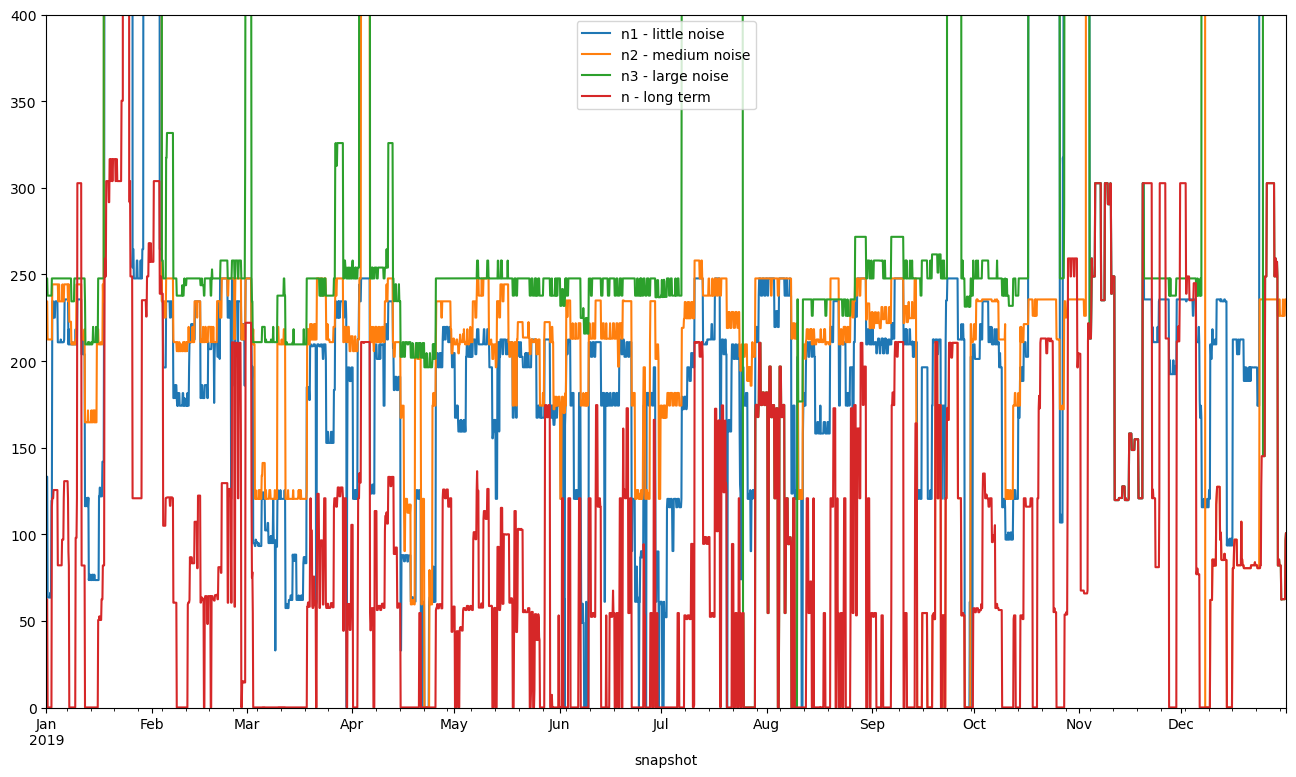

In [64]:
fig, ax = plt.subplots(figsize=(16,9))

for n, label in zip(networks, ['n1 - little noise', 'n2 - medium noise', 'n3 - large noise']):
    n.buses_t.marginal_price['DE0 0'].plot(
        ylim=(0,400),
        label = label
    )

n_lt.buses_t.marginal_price['DE0 0'].plot(
    ylim=(0, 400),
    label = 'n - long term'
)

plt.legend()

In [30]:
price_list = []
for n in networks:
    price_list.append(n.buses_t.marginal_price['DE0 0'])

real_price = n_lt.buses_t.marginal_price['DE0 0']

In [32]:
n_stochastic = prepare_profit_optimization_network()

n_stochastic.optimize.optimize_with_rolling_horizon(
    solver_name = "gurobi",
    extra_functionality = change_obj(price_list),
    horizon = horizon,
    overlap = 0
)

INFO:pypsa.io:Imported network base_s_1__none_2035_lt.nc has buses, carriers, generators, global_constraints, links, loads, storage_units, stores
{'DE', 'EU'}
INFO:pypsa.optimization.abstract:Optimizing network for snapshot horizon [2019-01-01 00:00:00:2019-01-18 21:00:00] (1/21).


2019-01-18 21:00:00


INFO:linopy.model: Solve problem using Gurobi solver


Set parameter Username


INFO:gurobipy:Set parameter Username


...

INFO:gurobipy:


Solved in 5 iterations and 0.02 seconds (0.00 work units)


INFO:gurobipy:Solved in 5 iterations and 0.02 seconds (0.00 work units)


Optimal objective  2.716107280e+07


INFO:gurobipy:Optimal objective  2.716107280e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 440 primals, 880 duals
Objective: 2.72e+07
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-energy_balance were not assigned to the network.


In [33]:
networks_deterministic = []

for i in range(0,3):
    n = prepare_profit_optimization_network()

    n.optimize.optimize_with_rolling_horizon(
        solver_name = "gurobi",
        extra_functionality = change_obj([price_list[i]]),
        horizon = horizon,
        overlap = 0,
    )

    networks_deterministic.append(n)

INFO:pypsa.io:Imported network base_s_1__none_2035_lt.nc has buses, carriers, generators, global_constraints, links, loads, storage_units, stores
{'DE', 'EU'}
INFO:pypsa.optimization.abstract:Optimizing network for snapshot horizon [2019-01-01 00:00:00:2019-01-18 21:00:00] (1/21).
INFO:linopy.model: Solve problem using Gurobi solver


2019-01-18 21:00:00
Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2637156


INFO:gurobipy:Set parameter LicenseID to value 2637156


...

INFO:gurobipy:


Solved in 10 iterations and 0.02 seconds (0.00 work units)


INFO:gurobipy:Solved in 10 iterations and 0.02 seconds (0.00 work units)


Optimal objective  7.765437153e+07


INFO:gurobipy:Optimal objective  7.765437153e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 440 primals, 880 duals
Objective: 7.77e+07
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-energy_balance were not assigned to the network.


In [27]:
def get_profit(n, price, start = 0, stop=1):

    # starting with the 2nd week
    start = start * 24
    stop = stop * 24
    discharge_2035 = n.links_t.p0["DE0 0 battery discharger-2035"]
    charge_2035 = n.links_t.p0["DE0 0 battery charger-2035"]
    discharge_2030 = n.links_t.p0["DE0 0 battery discharger-2030"]
    charge_2030 = n.links_t.p0["DE0 0 battery charger-2030"]


    expected_profit_35 = (-charge_2035[start:] * price[start:] * 1/n.links.efficiency["DE0 0 battery charger-2035"]  + discharge_2035[start:] * price[start:]).sum()
    expected_profit_30 = (-charge_2030[start:] * price[start:] * 1/n.links.efficiency["DE0 0 battery charger-2030"]  + discharge_2030[start:] * price[start:]).sum()

    return (expected_profit_35 + expected_profit_30)/10e8

In [54]:
profit = print_profits()


Profit in 10^8 €


,n1,n2,n3,n_stochastic
price 1,3.863674,3.014095,1.825868,3.767794
price 2,2.793165,3.526143,1.659251,3.382907
price 3,2.127903,1.938578,5.027236,3.779030
real_price,2.525281,2.713874,1.785150,2.525961
mean,2.827506,2.798172,2.574376,3.363923


In [46]:
from utils import tech_colors

LT


/opt/anaconda3/envs/price-formation/lib/python3.11/site-packages/pandas/plotting/_matplotlib/core.py:1800: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(None, 0)


Perfect Forecast


/opt/anaconda3/envs/price-formation/lib/python3.11/site-packages/pandas/plotting/_matplotlib/core.py:1800: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(None, 0)


Rolling Horizon


/opt/anaconda3/envs/price-formation/lib/python3.11/site-packages/pandas/plotting/_matplotlib/core.py:1800: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(None, 0)


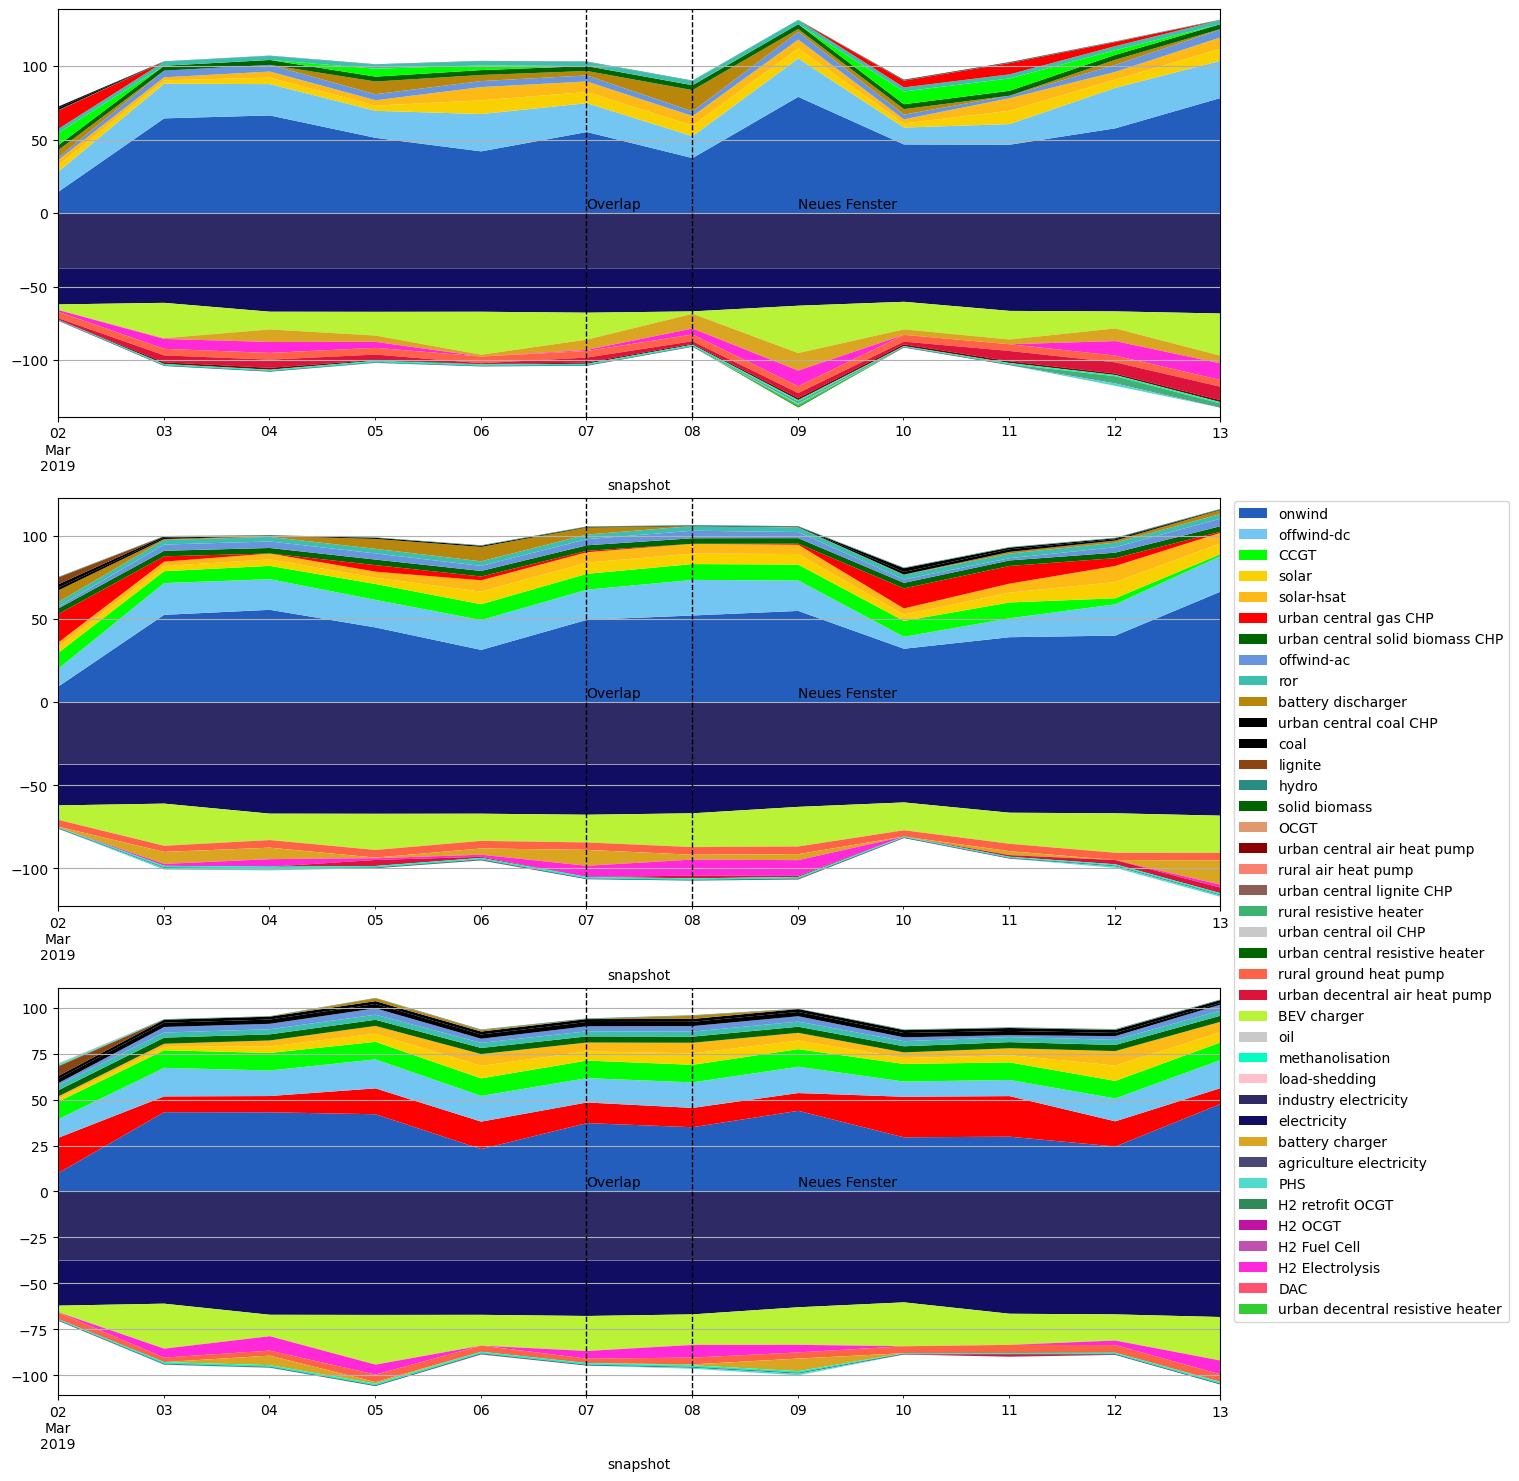

In [47]:
fig, ax = plt.subplots(3,1, figsize=(15,18))

for n, name, i in zip(networks, ["LT", "Perfect Forecast", "Rolling Horizon"], [0,1,2]):
    balance = (
        n.statistics.energy_balance(
            aggregate_time=False,
            nice_names=False,
        )
    )
    balance = (
        balance
        .groupby(["carrier", "bus_carrier"])
        .sum()
    )

    carriers = ["AC"]
    mask = balance.index.get_level_values("bus_carrier").isin(carriers)
    nb = balance[mask].groupby("carrier").sum().div(1e3).T[480:480+96]

    print(name)
    fig = plot_balance(nb, ax[i], tech_colors)
    ax[i].axvline(x=pd.Timestamp("2019-03-08 00:00"), linestyle='--', color='black', linewidth=1)
    ax[i].text(pd.Timestamp("2019-03-09 03:00:00"), 1.2, "Neues Fenster", rotation=0, color='black', va='bottom', ha='left')
    ax[i].axvline(x=pd.Timestamp("2019-03-07 00:00"), linestyle='--', color='black', linewidth=1)
    ax[i].text(pd.Timestamp("2019-03-07 03:00:00"), 1.2, "Overlap", rotation=0, color='black', va='bottom', ha='left')
    if i == 1:
        continue
    else:
        ax[i].legend().set_visible(False)


plt.show()
